In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score)

import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv('/content/KAG_conversion_data.csv')

# print the dataset

print(f" dataframe head : {df.head()}")
print(f" dataframe shape : {df.shape}")
print(f" dataframe info : {df.info()}")

# handling null values

print(f"null values : {df.isnull().sum()}")

print(f"columns : {df.columns}")

 dataframe head :     ad_id  xyz_campaign_id  fb_campaign_id    age gender  interest  \
0  708746              916          103916  30-34      M        15   
1  708749              916          103917  30-34      M        16   
2  708771              916          103920  30-34      M        20   
3  708815              916          103928  30-34      M        28   
4  708818              916          103928  30-34      M        28   

   Impressions  Clicks  Spent  Total_Conversion  Approved_Conversion  
0         7350       1   1.43                 2                    1  
1        17861       2   1.82                 2                    0  
2          693       0   0.00                 1                    0  
3         4259       1   1.25                 1                    0  
4         4133       1   1.29                 1                    1  
 dataframe shape : (1143, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns)

In [29]:
#df =df.drop(['ad_id'], axis = 1, inplace = True)
y = df['Approved_Conversion']
x = df.drop(['Approved_Conversion'], axis = 1)



scaler = StandardScaler()
Le = LabelEncoder()

for col in x:
  if x[col].dtype == "float64":
    x[col] = x[col].astype(int)
  elif x[col].dtype == "object":
    x[col] = Le.fit_transform(x[col])
  elif x[col].dtype == "int64" and col == "xyz_campaign_id" or col == "fb_campaign_id":
    x[col] = Le.fit_transform(x[col])
  else:
    x[col] = scaler.fit_transform(x[col].values.reshape(-1, 1))



In [30]:
print(x)

      xyz_campaign_id  fb_campaign_id  age  gender  interest  Impressions  \
0                   0               0    0       1 -0.659472    -0.573793   
1                   0               1    0       1 -0.622353    -0.540171   
2                   0               2    0       1 -0.473877    -0.595087   
3                   0               3    0       1 -0.176924    -0.583680   
4                   0               3    0       1 -0.176924    -0.584083   
...               ...             ...  ...     ...       ...          ...   
1138                2             686    3       0  2.829719     3.016521   
1139                2             687    3       0  2.866838     1.442036   
1140                2             688    3       0  2.903957    -0.112598   
1141                2             689    3       0  2.978196     1.930492   
1142                2             690    3       0  3.015315     1.044154   

        Clicks  Spent  Total_Conversion  
0    -0.569573      1         -0.

In [32]:
y.value_counts()

,count
Approved_Conversion,
0,559
1,403
2,86
3,35
4,24
5,7
6,7
8,5
10,4


In [46]:
value_counts = y.value_counts()

single_sample_classes = value_counts[value_counts < 2].index

if not single_sample_classes.empty:
    mask = ~y.isin(single_sample_classes)
    x = x[mask]
    y = y[mask]
    print(f"Removed {len(single_sample_classes)} classes with less than 2 samples: {single_sample_classes.tolist()}")

smote = SMOTE(random_state = 42, k_neighbors=1)
x, y = smote.fit_resample(x, y)

y.value_counts()

,count
Approved_Conversion,
1,559
0,559
3,559
2,559
14,559
5,559
10,559
4,559
9,559


In [40]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# Encode target labels to be 0 to num_class-1 for XGBoost multi-class
label_encoder_y = LabelEncoder()
y_train_encoded = label_encoder_y.fit_transform(y_train)
y_test_encoded = label_encoder_y.transform(y_test)

num_class = len(label_encoder_y.classes_) # Get the number of unique classes after encoding

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='merror', # Use merror for multi-class error rate
    objective='multi:softmax', # Use multi:softmax for multi-class classification
    num_class=num_class,     # Specify the number of classes
    tree_method='hist',
    n_jobs=-1
)

xgb_model.fit(x_train, y_train_encoded)
y_pred_encoded = xgb_model.predict(x_test)

accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
# For multi-class, precision, recall, f1_score need an 'average' parameter
precision = precision_score(y_test_encoded, y_pred_encoded, average='weighted')
recall = recall_score(y_test_encoded, y_pred_encoded, average='weighted')
f1 = f1_score(y_test_encoded, y_pred_encoded, average='weighted')

print(f"""
accuracy : {accuracy}
precision : {precision}
recall : {recall}
f1_score : {f1}
""")


accuracy : 0.9225037257824144
precision : 0.9196720132156679
recall : 0.9225037257824144
f1_score : 0.9208868127394509



In [41]:
y_train.value_counts()

,count
Approved_Conversion,
4,459
3,457
7,456
14,456
8,452
10,452
9,452
6,444
0,440


In [43]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test_encoded, y_pred_encoded))
cm = confusion_matrix(y_test_encoded, y_pred_encoded)
print(cm)
# generate confusion matrix code

              precision    recall  f1-score   support

           0       0.62      0.61      0.62       119
           1       0.62      0.57      0.59       125
           2       0.92      0.98      0.95       127
           3       0.99      1.00      1.00       102
           4       0.96      0.99      0.98       100
           5       1.00      1.00      1.00       127
           6       1.00      1.00      1.00       115
           7       1.00      1.00      1.00       103
           8       1.00      1.00      1.00       107
           9       1.00      1.00      1.00       107
          10       1.00      1.00      1.00       107
          11       1.00      1.00      1.00       103

    accuracy                           0.92      1342
   macro avg       0.93      0.93      0.93      1342
weighted avg       0.92      0.92      0.92      1342

[[ 73  42   3   0   1   0   0   0   0   0   0   0]
 [ 44  71   7   1   2   0   0   0   0   0   0   0]
 [  0   2 124   0   1   0   0  

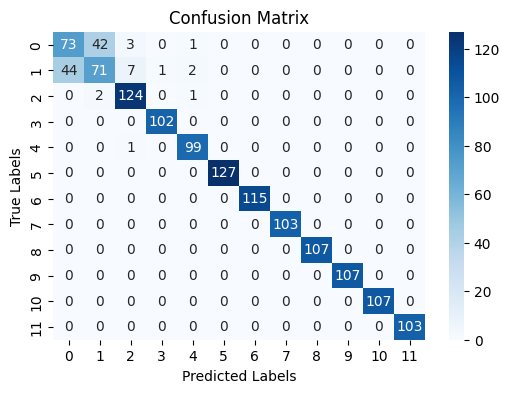

            feature  importance
8  Total_Conversion    0.383983
5       Impressions    0.120547
6            Clicks    0.096523
3            gender    0.095073
7             Spent    0.086465
1    fb_campaign_id    0.085471
4          interest    0.070410
2               age    0.042962
0   xyz_campaign_id    0.018567


['fraud_detection_model.pkl']

In [45]:
plt.figure(figsize = (6,4))
sns.heatmap(confusion_matrix(y_test_encoded, y_pred_encoded), annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({'feature': x.columns, 'importance': importance})
print(feature_importance.sort_values(by = 'importance', ascending = False))


import joblib

joblib.dump(xgb_model, "fraud_detection_model.pkl")

In [47]:
import joblib
joblib.dump(xgb_model, 'sales_conversion_model.pkl')
print(f" saved model")

 saved model
